This project is unfinished until I get a better GPU.

In [ ]:
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, List, Optional, Sequence

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision.io import read_image
from torchvision.transforms import functional as TF

def _sorted_frames(video_dir: Path) -> List[Path]:
    frames = [p for p in video_dir.iterdir() if p.suffix.lower() == ".jpg"]
    return sorted(frames, key=lambda p: p.name)

@dataclass
class _Clip:
    video_id: str
    indices: List[int]
    label: Optional[int]

class IPNHandFrames(Dataset):
    def __init__(
        self,
        frames_root: str | Path,
        annot_file: str | Path,
        clip_len: int = 16,
        resize_to: tuple[int,int] = (224,224),
        normalize: bool = True,
    ):
        self.root = Path(frames_root)
        self.clip_len = clip_len
        self.resize_to = resize_to
        self.normalize = normalize

        # Load video dirs
        self.videos: Dict[str, List[Path]] = {}
        for d in sorted(p for p in self.root.iterdir() if p.is_dir()):
            frames = _sorted_frames(d)
            if frames:
                self.videos[d.name] = frames

        # Parse annotations
        self.clips: List[_Clip] = []
        with open(annot_file, "r", encoding="utf-8") as f:
            for line in f:
                row = [x.strip() for x in line.strip().split(",")]
                if not row or row[0].startswith("#"):
                    continue
                vid = row[0]
                if vid not in self.videos:
                    continue
                raw_cid = int(row[2])
                class_id = raw_cid - 1

                start1 = int(row[3])
                end1 = int(row[4])

                frames = self.videos[vid]
                n = len(frames)
                seg_start0 = max(0, start1 - 1)
                seg_end0 = min(n, end1)
                
                if seg_end0 - seg_start0 < self.clip_len:
                    idxs = list(range(seg_start0, seg_end0))
                else:
                    mid = (seg_start0 + seg_end0 - self.clip_len) // 2
                    idxs = list(range(mid, mid + self.clip_len))

                self.clips.append(_Clip(vid, idxs, class_id))

    def __len__(self): return len(self.clips)

    def _load_frame(self, path: Path) -> torch.Tensor:
        img = read_image(str(path)).float() / 255.0
        if self.resize_to:
            img = TF.resize(img, self.resize_to, antialias=True)
        if self.normalize:
            mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
            std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
            img = (img - mean) / std
        return img

    def __getitem__(self, i: int):
        clip = self.clips[i]
        frames = self.videos[clip.video_id]
        imgs = [self._load_frame(frames[k]) for k in clip.indices if k < len(frames)]
        x = torch.stack(imgs, dim=0)   # [T,C,H,W]
        y = torch.tensor(clip.label, dtype=torch.long)
        return {"video_id": clip.video_id, "frames": x, "label": y}

def pad_collate(batch: Sequence[dict]):
    vids = [b["video_id"] for b in batch]
    ys = torch.stack([b["label"] for b in batch])
    xs = [b["frames"] for b in batch]
    T = max(t.shape[0] for t in xs)
    C,H,W = xs[0].shape[1:]
    out = torch.zeros((len(xs), T, C, H, W), dtype=xs[0].dtype)
    for i, t in enumerate(xs):
        out[i, :t.shape[0]] = t
        if t.shape[0] < T:
            out[i, t.shape[0]:] = t[-1:]
    return {"video_id": vids, "frames": out, "label": ys}

FRAMES_ROOT = "frames"
ANNOT_FILE = "annotations/Annot_TrainList.txt"

ds = IPNHandFrames(
    frames_root=FRAMES_ROOT,
    annot_file=ANNOT_FILE,
    clip_len=8,
)

dl = DataLoader(
    ds,
    batch_size=4,
    shuffle=True,
    num_workers=0,
    collate_fn=pad_collate,
)

# Print one batch shape
batch = next(iter(dl))
print("Frames:", batch["frames"].shape)  # [B,T,C,H,W]
print("Labels:", batch["label"].shape)
print("Video IDs:", batch["video_id"])


Frames: torch.Size([4, 8, 3, 224, 224])
Labels: torch.Size([4])
Video IDs: ['1CV12_2_R_#72', '1CM42_7_L_#202', '1CM42_9_R_#167', '1CV12_1_R_#66']


In [10]:
total_frames = sum(len(frames) for frames in ds.videos.values())
print(f"Total videos: {len(ds.videos)}")
print(f"Total frames: {total_frames}")
print(f"Total clips: {len(ds)}")

Total videos: 200
Total frames: 800491
Total clips: 4039


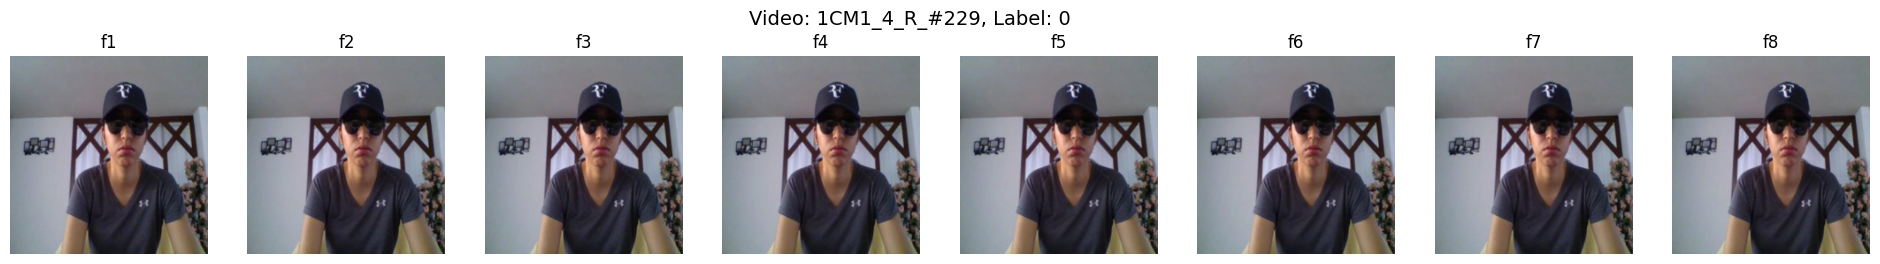

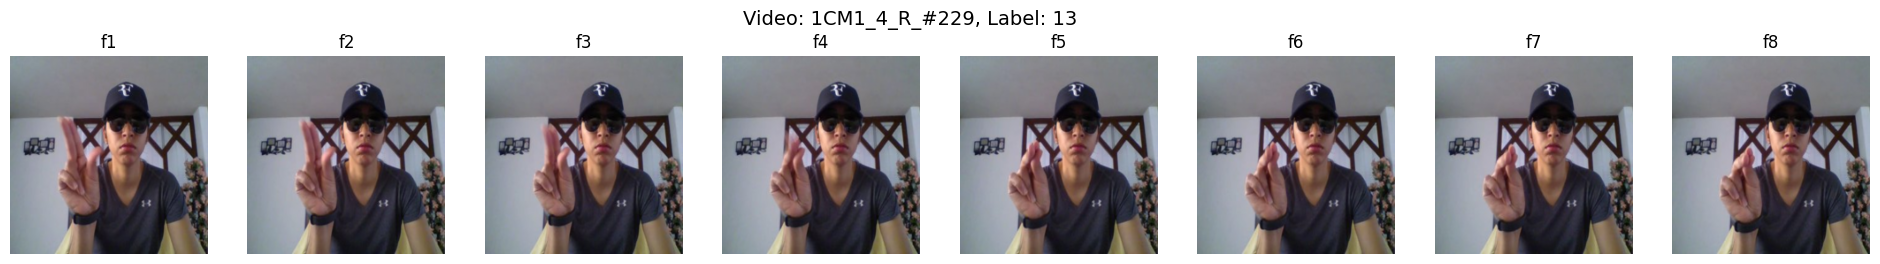

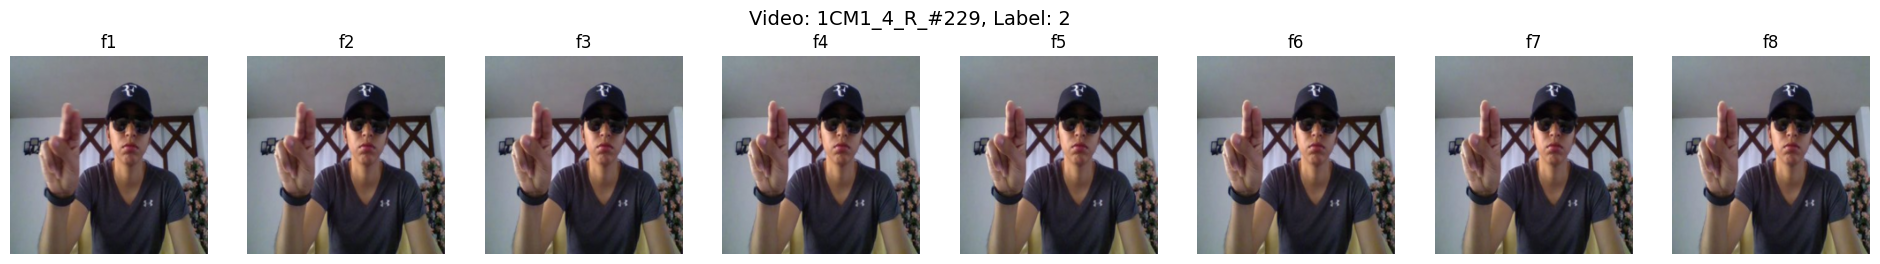

In [11]:
import matplotlib.pyplot as plt

def show_clip(batch_item, max_frames=8):
    frames = batch_item["frames"]  # [T,C,H,W]
    label = batch_item["label"].item()
    vid = batch_item["video_id"]

    T = min(frames.shape[0], max_frames)
    fig, axes = plt.subplots(1, T, figsize=(3*T, 3))
    if T == 1:
        axes = [axes]
    for i in range(T):
        img = frames[i].permute(1,2,0)  # CHW -> HWC
        img = img * torch.tensor([0.229,0.224,0.225]) + torch.tensor([0.485,0.456,0.406])
        img = img.clamp(0,1)
        axes[i].imshow(img)
        axes[i].axis("off")
        axes[i].set_title(f"f{i+1}")
    fig.suptitle(f"Video: {vid}, Label: {label}", fontsize=14)
    plt.show()

for i in range(3):
    item = ds[i]
    show_clip(item, max_frames=8)

![SampleI1](figures/Sample_image1.png)
![SampleI2](figures/Sample_image2.png)
![SampleI3](figures/Sample_image3.png)

In [1]:
from torch import nn

class TemporalShift(nn.Module):
    """
    Temporal shift.
    Assumes input is (N, channels, H, W) where N = BS * T where T is number of frames per sequence
    Reshape to (BS, T, channels, H, W), shift some channels, then flatten back.
    fold_div controls how many channels are shifted. Roughly 1/fold_div is shifted forward and 1/fold_div backwards.
    """
    def __init__(self, T, fold_div = 8):
        super().__init__()
        self.T = T
        self.fold_div = fold_div

    def forward(self, x):
        N, channels, H, W = x.shape

        BS = N // self.T
        x = x.view(BS, self.T, channels, H, W)  # (BS, T, channels, H, W)

        fold = channels // self.fold_div
        out = torch.zeros_like(x)

        # channel group 0..fold-1 uses previous time (t-1)
        out[:, 1:, :fold] = x[:, :-1, :fold]
        # channel group fold..2*fold-1 uses next time (t+1)
        out[:, :-1, fold:2*fold] = x[:, 1:, fold:2*fold]
        # rest unchanged
        out[:, :, 2*fold:] = x[:, :, 2*fold:]

        return out.view(N, channels, H, W)

Don't use TSM on layer 1, no need to shift an edge detector.

In [2]:
import torchvision.models as tv
from torch import nn, optim
import types

def add_tsm_inplace(model: nn.Module, T=8, fold_div=8):
    for layer in [model.layer2, model.layer3, model.layer4]:
        for i, block in enumerate(layer):
            layer[i] = nn.Sequential(TemporalShift(T, fold_div), block)

    # Method that accepts (B, T, 3, H, W)
    def video_forward(self, x):
        # x: (BS, T, 3, H, W)
        BS, T, channels, H, W = x.shape
        x = x.view(BS*T, channels, H, W)      # flatten time into batch
        logits = self(x)              # uses the existing FC head
        return logits.view(BS, T, -1).mean(dim=1)  # temporal consensus on logits

    model.video_forward = types.MethodType(video_forward, model)
    model.T = T
    model.fold_div = fold_div
    return model

c:\Users\rowes\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [24]:
from pathlib import Path
import torch
from torch import nn, optim
import torchvision.models as tv

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

resnet = tv.resnet34(weights=tv.ResNet34_Weights.IMAGENET1K_V1)
resnet = add_tsm_inplace(resnet, T=8, fold_div=8)
resnet.fc = nn.Linear(512, 14, bias=True)
resnet.to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.AdamW(resnet.parameters(), lr=3e-4, weight_decay=1e-4)

epochs = 20
best_acc = 0.0
save_dir = Path("ipn_tsm_resnet34")
save_dir.mkdir(parents=True, exist_ok=True)
best_path = save_dir / "best.pth"

for epoch in range(1, epochs + 1):
    resnet.train()
    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for step, batch in enumerate(dl, 1):
        xb = batch["frames"].to(device)  # [BS,T,channels,H,W]
        yb = batch["label"].to(device)   # [BS]

        optimizer.zero_grad(set_to_none=True)
        logits = resnet.video_forward(xb)   # [BS,14]
        loss = loss_fn(logits, yb)
        loss.backward()
        
        nn.utils.clip_grad_norm_(resnet.parameters(), 1.0)
        optimizer.step()

        running_loss += loss.item() * yb.size(0)
        preds = logits.argmax(1)
        running_correct += (preds == yb).sum().item()
        running_total += yb.size(0)

        if step % 50 == 0 or step == 1:
            avg_loss = running_loss / running_total
            avg_acc  = running_correct / running_total
            print(f"Epoch {epoch:02d} [{step:04d}/{len(dl):04d}] "
                  f"loss={avg_loss:.4f} acc={avg_acc:.3f}")

    epoch_loss = running_loss / running_total
    epoch_acc  = running_correct / running_total
    print(f"Epoch {epoch:02d} | loss={epoch_loss:.4f} acc={epoch_acc:.3f}")

    if epoch_acc > best_acc:
        best_acc = epoch_acc
        torch.save({
            "epoch": epoch,
            "model_state": resnet.state_dict(),
            "acc": epoch_acc
        }, best_path)
        print(f"New best acc: {best_acc:.3f} (saved to {best_path})")


Epoch 01 [0001/1010] loss=2.4470 acc=0.500
Epoch 01 [0050/1010] loss=2.4688 acc=0.240
Epoch 01 [0100/1010] loss=2.3867 acc=0.237
Epoch 01 [0150/1010] loss=2.3999 acc=0.223
Epoch 01 [0200/1010] loss=2.3626 acc=0.234
Epoch 01 [0250/1010] loss=2.3577 acc=0.232
Epoch 01 [0300/1010] loss=2.3515 acc=0.227
Epoch 01 [0350/1010] loss=2.3521 acc=0.228
Epoch 01 [0400/1010] loss=2.3392 acc=0.234
Epoch 01 [0450/1010] loss=2.3324 acc=0.236
Epoch 01 [0500/1010] loss=2.3427 acc=0.227
Epoch 01 [0550/1010] loss=2.3366 acc=0.230
Epoch 01 [0600/1010] loss=2.3448 acc=0.228
Epoch 01 [0650/1010] loss=2.3381 acc=0.232
Epoch 01 [0700/1010] loss=2.3393 acc=0.229
Epoch 01 [0750/1010] loss=2.3375 acc=0.231
Epoch 01 [0800/1010] loss=2.3417 acc=0.230
Epoch 01 [0850/1010] loss=2.3447 acc=0.229
Epoch 01 [0900/1010] loss=2.3434 acc=0.231
Epoch 01 [0950/1010] loss=2.3425 acc=0.233
Epoch 01 [1000/1010] loss=2.3369 acc=0.236
Epoch 01 | loss=2.3344 acc=0.238
New best acc: 0.238 (saved to ipn_tsm_resnet34\best.pth)
Epoch 0

In [ ]:
import torch
from torch.utils.data import DataLoader
import torchvision.models as tv
from torch import nn
from pathlib import Path

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

test_ds = IPNHandFrames(
    frames_root="frames",
    annot_file="annotations/Annot_TestList.txt",
    clip_len=8,
    resize_to=(224,224),
    normalize=True,
)
test_dl = DataLoader(test_ds, batch_size=4, shuffle=False, num_workers=0, collate_fn=pad_collate)

num_classes = 14
resnet = tv.resnet34(weights=None)
resnet = add_tsm_inplace(resnet, T=8, fold_div=8)
resnet.fc = nn.Linear(512, num_classes, bias=True)
resnet.to(device)
resnet.eval()

ckpt_path = Path("ipn_tsm_resnet34/best.pth")
ckpt = torch.load(ckpt_path, map_location=device)
state = ckpt["model_state"] if "model_state" in ckpt else ckpt
resnet.load_state_dict(state, strict=True)

correct = 0
total = 0
from collections import Counter
per_class_correct = Counter()
per_class_total = Counter()

with torch.inference_mode():
    for batch in test_dl:
        xb = batch["frames"].to(device)
        yb = batch["label"].to(device)
        logits = resnet.video_forward(xb)
        preds = logits.argmax(1)
        correct += (preds == yb).sum().item()
        total += yb.numel()
        for p, y in zip(preds.tolist(), yb.tolist()):
            per_class_total[y] += 1
            if p == y:
                per_class_correct[y] += 1

acc = correct / total if total else 0.0
print(f"Test accuracy: {acc:.3f}  ({correct}/{total})")

label_names = [
    "D0X","B0A","B0B","G01","G02","G03","G04",
    "G05","G06","G07","G08","G09","G10","G11"
]
for cid in range(num_classes):
    t = per_class_total[cid]
    c = per_class_correct[cid]
    if t > 0:
        print(f"{cid:2d} {label_names[cid]:>3}: {c}/{t} = {c/t:.3f}")



Test accuracy: 0.525  (846/1610)
 0 D0X: 236/509 = 0.464
 1 B0A: 154/265 = 0.581
 2 B0B: 183/264 = 0.693
 3 G01: 14/52 = 0.269
 4 G02: 10/52 = 0.192
 5 G03: 36/52 = 0.692
 6 G04: 31/52 = 0.596
 7 G05: 38/52 = 0.731
 8 G06: 32/52 = 0.615
 9 G07: 10/52 = 0.192
10 G08: 15/52 = 0.288
11 G09: 32/52 = 0.615
12 G10: 30/52 = 0.577
13 G11: 25/52 = 0.481


In [ ]:
import torch, numpy as np
from sklearn.metrics import confusion_matrix
all_y, all_p = [], []
with torch.inference_mode():
    for b in test_dl:
        xb, yb = b["frames"].to(device), b["label"].to(device)
        probs = torch.softmax(resnet.video_forward(xb), dim=-1)
        conf, pred = probs.max(1)
        # optional threshold:
        # pred = torch.where(conf < torch.tensor(0.6, device=pred.device), torch.tensor(0, device=pred.device), pred)
        all_y.append(yb.cpu().numpy())
        all_p.append(pred.cpu().numpy())
y = np.concatenate(all_y)
p = np.concatenate(all_p)
cm = confusion_matrix(y, p, labels=list(range(14)))
print(cm)


[[236  16  12  23  14  41  46  46  10  28   4   6   1  26]
 [ 10 154  60   9   0   3   1  19   2   1   5   0   1   0]
 [ 12  33 183   3   2   0   2  13   5   1   0   3   2   5]
 [  7  10   0  14   0   6   2   2   0   0  10   0   0   1]
 [  2   0   9   0  10   1   6   1   0   0   2  20   1   0]
 [  5   1   2   0   0  36   3   1   0   1   1   2   0   0]
 [  6   0   4   2   1   3  31   0   2   2   0   0   0   1]
 [  7   1   1   0   0   2   0  38   1   1   0   0   0   1]
 [  6   0   2   0   0   0   0   9  32   1   0   1   0   1]
 [  6   1   2   6   0   9   2   1   3  10   1   3   6   2]
 [  6   7   1  11   0   1   4   1   1   1  15   3   0   1]
 [  2   0   5   2   3   2   1   0   0   0   0  32   4   1]
 [  1   0   4   0   3   0   0   0   5   0   0   5  30   4]
 [  2   2   4   0   3   1   1   3   1   2   4   1   3  25]]


In [ ]:
import torch, numpy as np
import torch.nn.functional as F
from collections import Counter

def eval_with_bg_threshold(model, loader, tau=0.60, device="cuda"):
    model.eval()
    tot, correct = 0, 0
    pc_c, pc_t = Counter(), Counter()

    with torch.inference_mode():
        for b in loader:
            xb = b["frames"].to(device)
            yb = b["label"].to(device)

            probs = F.softmax(model.video_forward(xb), dim=-1)
            conf, pred = probs.max(1)
            # apply background threshold
            pred = torch.where(conf < tau, torch.tensor(0, device=pred.device), pred)

            correct += (pred == yb).sum().item()
            tot += yb.numel()

            for p, y in zip(pred.tolist(), yb.tolist()):
                pc_t[y] += 1
                if p == y:
                    pc_c[y] += 1

    acc = correct / tot if tot else 0
    return acc, pc_c, pc_t

TAU = 0.90
device = "cuda" if torch.cuda.is_available() else "cpu"

acc, pc_c, pc_t = eval_with_bg_threshold(resnet, test_dl, tau=TAU, device=device)

print(f"Thresholded Test Accuracy: {acc:.3f}")
for cid in range(14):
    t = pc_t[cid]
    c = pc_c[cid]
    if t > 0:
        print(f"{cid:2d}: {c}/{t} = {c/t:.3f}")


Thresholded Test Accuracy: 0.556
 0: 407/509 = 0.800
 1: 125/265 = 0.472
 2: 165/264 = 0.625
 3: 8/52 = 0.154
 4: 3/52 = 0.058
 5: 26/52 = 0.500
 6: 26/52 = 0.500
 7: 38/52 = 0.731
 8: 28/52 = 0.538
 9: 3/52 = 0.058
10: 8/52 = 0.154
11: 19/52 = 0.365
12: 25/52 = 0.481
13: 14/52 = 0.269


In [ ]:
import torch, numpy as np
from sklearn.metrics import confusion_matrix
all_y, all_p = [], []
with torch.inference_mode():
    for b in test_dl:
        xb, yb = b["frames"].to(device), b["label"].to(device)
        probs = torch.softmax(resnet.video_forward(xb), dim=-1)
        conf, pred = probs.max(1)
        pred = torch.where(conf < torch.tensor(0.6, device=pred.device), torch.tensor(0, device=pred.device), pred)
        all_y.append(yb.cpu().numpy())
        all_p.append(pred.cpu().numpy())
y = np.concatenate(all_y)
p = np.concatenate(all_p)
cm = confusion_matrix(y, p, labels=list(range(14)))
print(cm)

[[310  12   7  18   8  26  39  38  10  22   2   0   1  16]
 [ 29 149  53   8   0   3   0  16   2   0   4   0   1   0]
 [ 29  27 178   3   2   0   2  11   4   0   0   3   2   3]
 [ 20   7   0  12   0   2   2   2   0   0   6   0   0   1]
 [ 13   0   6   0   8   1   5   1   0   0   0  17   1   0]
 [ 10   1   2   0   0  33   2   1   0   1   1   1   0   0]
 [ 11   0   3   1   0   2  31   0   2   1   0   0   0   1]
 [  8   1   1   0   0   2   0  38   1   0   0   0   0   1]
 [ 13   0   2   0   0   0   0   6  28   1   0   1   0   1]
 [ 17   1   1   4   0   7   1   1   3   9   0   2   4   2]
 [ 14   7   1  10   0   1   3   1   1   0  13   1   0   0]
 [ 12   0   5   1   3   1   0   0   0   0   0  27   3   0]
 [  9   0   4   0   0   0   0   0   4   0   0   4  30   1]
 [ 13   2   4   0   2   1   0   3   1   2   2   0   3  19]]


Removing G01 (Click with one finger), G02 (Click with 2 fingers), G07 (Open twice) and merging G08 (Double click with one finger) and G09 (Double click with two fingers). Through the confusion matrix, accuracy metrics, and analyzation of how the classes compare to each other, I decided to get rid of some classes. They were very similar to other classes, had low accuracy, and weren't useful for my project. I am also adding different learning rates for the backbone of the model and the head, the head needs a higher learning rate. Though training accuracy was quite high, test accuracy was very low. To monitor better I am adding a validation split (10%) to monitor overfitting. I don't think 8 frames covered enough, so I upped it to 16. I also lowered batch size to 2 and resized the image to 160x160.

In [ ]:
""""import torch, random, numpy as np, matplotlib.pyplot as plt
from torchvision.transforms import functional as TF

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = resnet.eval().to(device)

label_names = [
    "D0X","B0A","B0B","G01","G02","G03","G04",
    "G05","G06","G07","G08","G09","G10","G11"
]

# convenience for denormalizing to 0–255
mean = np.array([0.485,0.456,0.406]).reshape(3,1,1)
std  = np.array([0.229,0.224,0.225]).reshape(3,1,1)

# pick 10 random indices
idxs = random.sample(range(len(ds)), 10)

for idx in idxs:
    sample = ds[idx]
    x = sample["frames"]              # [T,C,H,W], normalized
    y = sample["label"].item()        # ground truth
    T, C, H, W = x.shape

    with torch.inference_mode():
        xb = x.unsqueeze(0).to(device)
        logits = model.video_forward(xb)[0]
        probs = torch.softmax(logits, dim=-1).cpu().numpy()
    pred_id = int(probs.argmax())
    pred_name = label_names[pred_id]
    conf = float(probs[pred_id])
    true_name = label_names[y]

    # denormalize and make grid
    frames = []
    for t in range(T):
        im = x[t].numpy()
        im = (im * std + mean)
        im = np.clip(im * 255, 0, 255).astype(np.uint8)
        im = np.transpose(im, (1,2,0))
        frames.append(im)

    cols = min(T, 8)
    rows = int(np.ceil(T / cols))
    tile = np.zeros((rows*H, cols*W, 3), dtype=np.uint8)
    for i, im in enumerate(frames):
        r, c = divmod(i, cols)
        tile[r*H:(r+1)*H, c*W:(c+1)*W] = im

    title = f"Pred: {pred_name} ({conf:.2f}) | True: {true_name}"
    plt.figure(figsize=(12, 6))
    plt.imshow(tile)
    plt.axis("off")
    plt.title(title)
    plt.show()
""""

In [ ]:
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, List, Optional, Sequence

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision.io import read_image
from torchvision.transforms import functional as TF

def _sorted_frames(video_dir: Path) -> List[Path]:
    frames = [p for p in video_dir.iterdir() if p.suffix.lower() == ".jpg"]
    return sorted(frames, key=lambda p: p.name)

@dataclass
class _Clip:
    video_id: str
    indices: List[int]
    label: Optional[int]

class IPNHandFrames(Dataset):
    """
      Drops classes: G01, G02, G07
      - Merges G08 + G09 into a single class
      - Remaps to contiguous [0..K-1], keeping D0X (raw=1) at index 0
    """
    def __init__(
        self,
        frames_root: str | Path,
        annot_file: str | Path,
        clip_len: int = 16,
        resize_to: tuple[int,int] = (224,224),
        normalize: bool = True,
    ):
        self.root = Path(frames_root)
        self.clip_len = clip_len
        self.resize_to = resize_to
        self.normalize = normalize

        self._raw_label_names = [
            "D0X","B0A","B0B","G01","G02","G03","G04",
            "G05","G06","G07","G08","G09","G10","G11"
        ]

        drop_raw_ids = {4, 5, 10}           # remove G01, G02, G07
        merge_pairs  = [(11, 12)]           # merge G08 + G09

        merge_groups: List[set] = [set(p) for p in merge_pairs]
        rep_for: Dict[int,int] = {}
        for g in merge_groups:
            rep = min(g)
            for r in g:
                rep_for[r] = rep

        kept_reps_ordered: List[int] = []
        seen = set()
        raw_ids_in_order = list(range(1, 15))
        for raw in raw_ids_in_order:
            if raw in drop_raw_ids:
                continue
            rep = rep_for.get(raw, raw)
            if rep not in seen:
                kept_reps_ordered.append(rep)
                seen.add(rep)

        if 1 in kept_reps_ordered:
            kept_reps_ordered = [1] + [r for r in kept_reps_ordered if r != 1]

        self._raw2new: Dict[int,int] = {}
        self.new_label_names: List[str] = []
        for new_idx, rep_raw in enumerate(kept_reps_ordered):
            if any(rep_raw in g for g in merge_groups):
                grp = next(iter(g for g in merge_groups if rep_raw in g))
                grp_sorted = sorted(list(grp))
                name = "_".join(self._raw_label_names[r-1] for r in grp_sorted)
            else:
                name = self._raw_label_names[rep_raw-1]
            self.new_label_names.append(name)
            self._raw2new[rep_raw] = new_idx
            for g in merge_groups:
                if rep_raw in g:
                    for r in g:
                        self._raw2new[r] = new_idx

        self.videos: Dict[str, List[Path]] = {}
        for d in sorted(p for p in self.root.iterdir() if p.is_dir()):
            frames = _sorted_frames(d)
            if frames:
                self.videos[d.name] = frames

        self.clips: List[_Clip] = []
        with open(annot_file, "r", encoding="utf-8") as f:
            for line in f:
                row = [x.strip() for x in line.strip().split(",")]
                if not row or row[0].startswith("#"):
                    continue
                vid = row[0]
                if vid not in self.videos:
                    continue

                raw_cid = int(row[2])
                if raw_cid in drop_raw_ids:
                    continue
                if raw_cid not in self._raw2new:
                    continue

                new_cid = self._raw2new[raw_cid]

                start1 = int(row[3])
                end1 = int(row[4])
                frames = self.videos[vid]
                n = len(frames)

                seg_start0 = max(0, start1 - 1)
                seg_end0 = min(n, end1)

                if seg_end0 - seg_start0 < self.clip_len:
                    idxs = list(range(seg_start0, seg_end0))
                else:
                    mid = (seg_start0 + seg_end0 - self.clip_len) // 2
                    idxs = list(range(mid, mid + self.clip_len))

                self.clips.append(_Clip(vid, idxs, new_cid))

        self._mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
        self._std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

    def __len__(self): 
        return len(self.clips)

    def _load_frame(self, path: Path) -> torch.Tensor:
        img = read_image(str(path)).float() / 255.0
        if self.resize_to:
            img = TF.resize(img, self.resize_to, antialias=True)
        if self.normalize:
            img = (img - self._mean) / self._std
        return img

    def __getitem__(self, i: int):
        clip = self.clips[i]
        frames = self.videos[clip.video_id]
        imgs = [self._load_frame(frames[k]) for k in clip.indices if k < len(frames)]
        x = torch.stack(imgs, dim=0)
        y = torch.tensor(clip.label, dtype=torch.long)
        return {"video_id": clip.video_id, "frames": x, "label": y}

def pad_collate(batch: Sequence[dict]):
    vids = [b["video_id"] for b in batch]
    ys = torch.stack([b["label"] for b in batch])
    xs = [b["frames"] for b in batch]
    T = max(t.shape[0] for t in xs)
    C,H,W = xs[0].shape[1:]
    out = torch.zeros((len(xs), T, C, H, W), dtype=xs[0].dtype)
    for i, t in enumerate(xs):
        out[i, :t.shape[0]] = t
        if t.shape[0] < T:
            out[i, t.shape[0]:] = t[-1:]
    return {"video_id": vids, "frames": out, "label": ys}

In [ ]:
from pathlib import Path
import torch
from torch.utils.data import DataLoader, random_split

FRAMES_ROOT = "frames"
TRAIN_ANN = "annotations/Annot_TrainList.txt"
TEST_ANN = "annotations/Annot_TestList.txt"

ds_full = IPNHandFrames(frames_root=FRAMES_ROOT, annot_file=TRAIN_ANN,
                         clip_len=16, resize_to=(160,160))
ds_test = IPNHandFrames(frames_root=FRAMES_ROOT, annot_file=TEST_ANN,
                         clip_len=16, resize_to=(160,160))

print("New classes:", ds_full.new_label_names)
num_classes = len(ds_full.new_label_names)

val_frac = 0.1
val_len = int(len(ds_full) * val_frac)
train_len = len(ds_full) - val_len
train_ds, val_ds = random_split(ds_full, [train_len, val_len],
                                generator=torch.Generator().manual_seed(42))

train_dl = DataLoader(train_ds, batch_size=2, shuffle=True, num_workers=0, collate_fn=pad_collate)
val_dl = DataLoader(val_ds, batch_size=2, shuffle=False, num_workers=0, collate_fn=pad_collate)
test_dl = DataLoader(ds_test, batch_size=2, shuffle=False, num_workers=0, collate_fn=pad_collate)

batch = next(iter(train_dl))
print("Frames:", batch["frames"].shape)
print("Labels:", batch["label"].shape)
print("Video IDs:", batch["video_id"])


New classes: ['D0X', 'B0A', 'B0B', 'G03', 'G04', 'G05', 'G06', 'G08_G09', 'G10', 'G11']
Frames: torch.Size([2, 16, 3, 160, 160])
Labels: torch.Size([2])
Video IDs: ['4CM11_11_R_#4', '1CM42_26_R_#173']


In [ ]:
import math, numpy as np
import torchvision.models as tv
from torch import nn, optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

resnet = tv.resnet34(weights=tv.ResNet34_Weights.IMAGENET1K_V1)
resnet = add_tsm_inplace(resnet, T=16, fold_div=8)
resnet.fc = nn.Sequential(nn.Dropout(p=0.2), nn.Linear(512, num_classes, bias=True))
resnet.to(device)

loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)

head_params = list(resnet.fc.parameters())
backbone_params = [p for n,p in resnet.named_parameters() if not n.startswith("fc.")]
optimizer = optim.AdamW(
    [{"params": backbone_params, "lr": 2e-4},
     {"params": head_params,     "lr": 6e-4}],
    weight_decay=1e-3,
)
epochs = 25
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

best_val_acc = 0.0
save_dir = Path("ipn_tsm_resnet34_10cls")
save_dir.mkdir(parents=True, exist_ok=True)
best_path = save_dir / "best.pth"

for epoch in range(1, epochs + 1):
    resnet.train()
    run_loss = 0.0
    run_correct = 0
    run_total = 0
    for step, batch in enumerate(train_dl, 1):
        xb = batch["frames"].to(device)
        yb = batch["label"].to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = resnet.video_forward(xb)
        loss = loss_fn(logits, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(resnet.parameters(), 1.0)
        optimizer.step()

        run_loss += loss.item() * yb.size(0)
        preds = logits.argmax(1)
        run_correct += (preds == yb).sum().item()
        run_total += yb.size(0)

        if step % 200 == 0:
            print(f"Epoch {epoch:02d} [train {step:04d}/{len(train_dl):04d}] "
                  f"loss={(run_loss/run_total):.4f} acc={(run_correct/run_total):.3f}")

    train_loss = run_loss / run_total
    train_acc  = run_correct / run_total

    resnet.eval()
    v_correct = 0
    v_total = 0
    v_loss_sum = 0.0
    with torch.inference_mode():
        for batch in val_dl:
            xb = batch["frames"].to(device)
            yb = batch["label"].to(device)
            logits = resnet.video_forward(xb)
            loss = loss_fn(logits, yb)
            preds = logits.argmax(1)
            v_correct += (preds == yb).sum().item()
            v_total += yb.numel()
            v_loss_sum += loss.item() * yb.size(0)

    val_loss = v_loss_sum / v_total
    val_acc = v_correct / v_total
    scheduler.step()

    print(f"Epoch {epoch:02d} | train loss={train_loss:.4f} acc={train_acc:.3f} "
          f"| val loss={val_loss:.4f} acc={val_acc:.3f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({"epoch": epoch, "model_state": resnet.state_dict(), "val_acc": val_acc}, best_path)
        print(f"New best val acc: {best_val_acc:.3f} (saved to {best_path})")

Epoch 01 [train 0200/1618] loss=2.2116 acc=0.212
Epoch 01 [train 0400/1618] loss=2.1726 acc=0.233
Epoch 01 [train 0600/1618] loss=2.1539 acc=0.248
Epoch 01 [train 0800/1618] loss=2.1413 acc=0.263
Epoch 01 [train 1000/1618] loss=2.1198 acc=0.278
Epoch 01 [train 1200/1618] loss=2.1061 acc=0.278
Epoch 01 [train 1400/1618] loss=2.0925 acc=0.284
Epoch 01 [train 1600/1618] loss=2.0847 acc=0.286
Epoch 01 | train loss=2.0860 acc=0.286 | val loss=2.0038 acc=0.423
New best val acc: 0.423 (saved to ipn_tsm_resnet34_10cls\best.pth)
Epoch 02 [train 0200/1618] loss=1.9325 acc=0.367
Epoch 02 [train 0400/1618] loss=1.9073 acc=0.362
Epoch 02 [train 0600/1618] loss=1.9032 acc=0.368
Epoch 02 [train 0800/1618] loss=1.8714 acc=0.382
Epoch 02 [train 1000/1618] loss=1.8560 acc=0.385
Epoch 02 [train 1200/1618] loss=1.8395 acc=0.389
Epoch 02 [train 1400/1618] loss=1.8179 acc=0.396
Epoch 02 [train 1600/1618] loss=1.8122 acc=0.399
Epoch 02 | train loss=1.8113 acc=0.400 | val loss=1.5986 acc=0.448
New best val ac

RuntimeError: shape '[1, 16, 64, 40, 40]' is invalid for input of size 3072000

In [47]:
import torch, numpy as np
import torch.nn.functional as F
from collections import Counter
from torch import nn

device = "cuda" if torch.cuda.is_available() else "cpu"
ckpt_path = "ipn_tsm_resnet34_10cls/best.pth"
ckpt = torch.load(ckpt_path, map_location=device)
resnet.load_state_dict(ckpt["model_state"], strict=True)
resnet.to(device).eval()

NUM_CLASSES = 10

def eval_with_bg_threshold(model, loader, tau=0.60, device="cuda", bg_idx=0):
    model.eval()
    tot, correct = 0, 0
    pc_c, pc_t = Counter(), Counter()

    with torch.inference_mode():
        for b in loader:
            xb = b["frames"].to(device)
            yb = b["label"].to(device)

            T_need = getattr(model, "T", xb.shape[1])
            B, T_have, C, H, W = xb.shape
            if T_have != T_need:
                if T_have > T_need:
                    xb = xb[:, :T_need]
                else:
                    pad = xb[:, -1:].expand(B, T_need - T_have, C, H, W)
                    xb = torch.cat([xb, pad], dim=1)

            probs = F.softmax(model.video_forward(xb), dim=-1)
            conf, pred = probs.max(1)
            pred = torch.where(conf < tau, torch.tensor(bg_idx, device=pred.device), pred)

            correct += (pred == yb).sum().item()
            tot += yb.numel()

            for p, y in zip(pred.tolist(), yb.tolist()):
                pc_t[y] += 1
                if p == y:
                    pc_c[y] += 1

    acc = correct / tot if tot else 0.0
    return acc, pc_c, pc_t

TAU = 0.60
acc, pc_c, pc_t = eval_with_bg_threshold(resnet, test_dl, tau=TAU, device=device, bg_idx=0)

print(f"Thresholded Test Accuracy: {acc:.3f}")
for cid in range(NUM_CLASSES):
    t = pc_t[cid]
    c = pc_c[cid]
    if t > 0:
        print(f"{cid:2d}: {c}/{t} = {c/t:.3f}")


Thresholded Test Accuracy: 0.671
 0: 384/509 = 0.754
 1: 186/265 = 0.702
 2: 147/264 = 0.557
 3: 30/52 = 0.577
 4: 36/52 = 0.692
 5: 33/52 = 0.635
 6: 43/52 = 0.827
 7: 62/104 = 0.596
 8: 27/52 = 0.519
 9: 28/52 = 0.538


In [ ]:
import numpy as np
import torch
import torch.nn.functional as F

BG_IDX = 0

def collect_probs(model, loader, device):
    model.eval()
    Ps, Ys = [], []
    with torch.inference_mode():
        for b in loader:
            x, y = b["frames"].to(device), b["label"].to(device)

            T_need = getattr(model, "T", x.shape[1])
            if x.shape[1] != T_need:
                if x.shape[1] > T_need:
                    x = x[:, :T_need]
                else:
                    pad = x[:, -1:].expand(x.size(0), T_need-x.size(1), *x.shape[2:])
                    x = torch.cat([x, pad], dim=1)

            p = F.softmax(model.video_forward(x), dim=-1)
            Ps.append(p.cpu())
            Ys.append(y.cpu())
    return torch.cat(Ps), torch.cat(Ys)

def learn_classwise_taus(model, val_loader, device, grid=(0.35, 0.80, 19), optimize="acc"):
    probs, y = collect_probs(model, val_loader, device)
    conf, pred = probs.max(dim=1)
    N, K = probs.shape
    taus = np.full(K, 0.60, dtype=np.float32)

    lo, hi, steps = grid
    grid_vals = np.linspace(lo, hi, steps)

    for k in range(K):
        if k == BG_IDX:
            continue

        best_tau, best_score = 0.60, -1.0
        mask_k = (pred == k)

        if mask_k.sum().item() == 0:
            continue

        for tau in grid_vals:
            new_pred = pred.clone()
            low_k = mask_k & (conf < tau)
            new_pred[low_k] = BG_IDX

            if optimize == "acc":
                score = (new_pred == y).float().mean().item()
            elif optimize == "f1":
                tp = ((new_pred == k) & (y == k)).sum().item()
                fp = ((new_pred == k) & (y != k)).sum().item()
                fn = ((new_pred != k) & (y == k)).sum().item()
                precision = tp / (tp + fp + 1e-9)
                recall = tp / (tp + fn + 1e-9)
                score = 2 * precision * recall / (precision + recall + 1e-9)
            else:
                raise ValueError("optimize must be 'acc' or 'f1'")

            if score > best_score:
                best_score, best_tau = score, float(tau)

        taus[k] = best_tau

    return taus

def predict_with_classwise_taus(model, x, taus, device, bg_idx=0):
    # Clamp T
    T_need = getattr(model, "T", x.shape[1])
    if x.shape[1] != T_need:
        if x.shape[1] > T_need:
            x = x[:, :T_need]
        else:
            pad = x[:, -1:].expand(x.size(0), T_need-x.size(1), *x.shape[2:])
            x = torch.cat([x, pad], dim=1)

    p = F.softmax(model.video_forward(x), dim=-1)
    conf, pred = p.max(1)
    tau_vec = torch.tensor(taus, device=p.device)[pred]
    pred = torch.where(conf < tau_vec, torch.tensor(bg_idx, device=p.device), pred)
    return pred

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

taus = learn_classwise_taus(resnet, val_dl, device, grid=(0.35, 0.80, 19), optimize="acc")
print("Learned per-class taus:", np.round(taus, 3))

from collections import Counter
resnet.eval()
tot = 0
corr = 0
pc_c = Counter()
pc_t = Counter()

with torch.inference_mode():
    for b in test_dl:
        xb = b["frames"].to(device)
        yb = b["label"].to(device)
        pred = predict_with_classwise_taus(resnet, xb, taus, device, bg_idx=BG_IDX)
        corr += (pred == yb).sum().item()
        tot += yb.numel()
        for p,y in zip(pred.tolist(), yb.tolist()):
            pc_t[y]+=1
            pc_c[y]+= int(p==y)

acc = corr/tot
print(f"Test acc with classwise taus: {acc:.3f}")
for cid in range(len(taus)):
    if pc_t[cid]>0:
        print(f"{cid:2d}: {pc_c[cid]}/{pc_t[cid]} = {pc_c[cid]/pc_t[cid]:.3f}")


Learned per-class taus: [0.6  0.35 0.35 0.35 0.35 0.35 0.35 0.45 0.45 0.35]
Test acc with classwise taus: 0.670
 0: 345/509 = 0.678
 1: 201/265 = 0.758
 2: 155/264 = 0.587
 3: 31/52 = 0.596
 4: 38/52 = 0.731
 5: 35/52 = 0.673
 6: 45/52 = 0.865
 7: 66/104 = 0.635
 8: 28/52 = 0.538
 9: 30/52 = 0.577


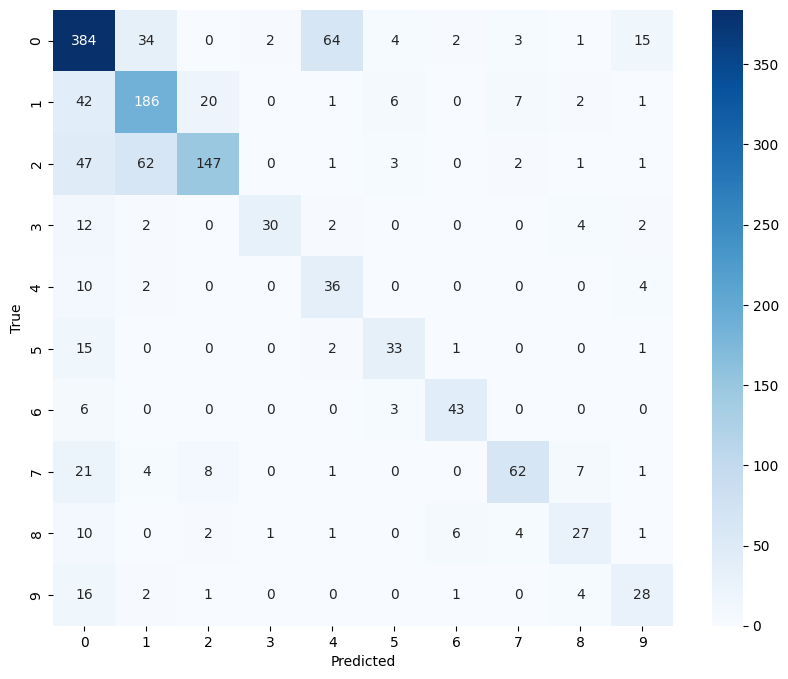

In [53]:
import torch, numpy as np
from sklearn.metrics import confusion_matrix

device = "cuda" if torch.cuda.is_available() else "cpu"
NUM_CLASSES = 10

all_y, all_p = [], []

resnet.eval()
with torch.inference_mode():
    for b in test_dl:
        xb, yb = b["frames"].to(device), b["label"].to(device)

        T_need = getattr(resnet, "T", xb.shape[1])
        if xb.shape[1] != T_need:
            if xb.shape[1] > T_need:
                xb = xb[:, :T_need]
            else:
                pad = xb[:, -1:].expand(xb.size(0), T_need - xb.size(1), *xb.shape[2:])
                xb = torch.cat([xb, pad], dim=1)

        probs = torch.softmax(resnet.video_forward(xb), dim=-1)
        conf, pred = probs.max(1)

        pred = torch.where(conf < torch.tensor(0.6, device=pred.device),
                           torch.tensor(0, device=pred.device), pred)

        all_y.append(yb.cpu().numpy())
        all_p.append(pred.cpu().numpy())

y = np.concatenate(all_y)
p = np.concatenate(all_p)
cm = confusion_matrix(y, p, labels=list(range(NUM_CLASSES)))

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()



Biggest problem is the 64 predicted 4 actual 0. I don't want the LED lights to be randomly picking up gestures when nothing is happening. I checked every single one of those 64 clips and they are unacceptable mistakes. Goal for next model is to get rid of that. I am fine with the model overpredicting background, that isn't a problem, but when it predicts a gesture when it's supposed to be background, that's where it's a problem.

- Diff Stream is a secnd model that reads frame differences instead of RGB. It emphasizes motion and reduces false triggers from static frames. It feeds through the TSM-ResNet and averages its logits with the RGB model.
- BG Margin regularizer is an extra loss term that enforces a margin between background and gestures. It makes the model default to background unless evidence is clear.
- EMA is an exponential moving average of model weights, it is smoother and better generalizing.
- Multiclip logits average logits from multiple overlapping temporal windows of a clip. It stabilizes predictions and raises recall on partial gestures.
- TempScale learns a single scalar T to calibrate logits.
- BG Bias subtracts a constant from all non-background logits at inference to favour background.
- Macro-F1 averaged over gesture classes only, excluding background. It prevents the model from thinking that predicting background always is a good idea.
- Sweep Thresholds does a grid search to meet a false positive target and maximize macro-F1.

In [ ]:
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, List, Optional, Sequence
import os, random, math, json, numpy as np
import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader, Subset, WeightedRandomSampler
from torchvision.io import read_image
from torchvision.transforms import functional as TF
import torchvision.models as tv
from torch.cuda.amp import autocast, GradScaler

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True

AMP_ENABLED = False
NAN_SKIP_AND_LOG = True

def _sorted_frames(video_dir: Path) -> List[Path]:
    fs = [p for p in video_dir.iterdir() if p.suffix.lower() == ".jpg"]
    return sorted(fs, key=lambda p: p.name)

def _resize_keep_aspect(img: torch.Tensor, short_side: int) -> torch.Tensor:
    _, H, W = img.shape
    s = short_side / min(H, W)
    newH, newW = int(round(H*s)), int(round(W*s))
    return TF.resize(img, [newH, newW], antialias=True)

def _random_or_center_crop(img: torch.Tensor, size: int, train: bool) -> torch.Tensor:
    if train:
        H, W = img.shape[1:]
        top = random.randint(0, max(0, H - size))
        left = random.randint(0, max(0, W - size))
        img = TF.crop(img, top, left, min(size, H), min(size, W))
        if random.random() < 0.5:
            img = TF.hflip(img)
        return img
    else:
        return TF.center_crop(img, [size, size])

@dataclass
class _Clip:
    video_id: str
    indices: List[int]
    label: Optional[int]

class IPNHandFrames(Dataset):
    """
    Drops: G01, G02, G07
    merges: G08+G09
    keeps D0X at index 0.
    """
    def __init__(self, frames_root, annot_file, clip_len=16, crop_size=160, short_side=256,
                 normalize=True, train=True, add_near_bg=False, near=32):
        self.root = Path(frames_root)
        self.clip_len = clip_len
        self.crop_size = crop_size
        self.short_side = short_side
        self.normalize = normalize
        self.train = train
        self.add_near_bg = add_near_bg
        self.near = near

        names = ["D0X","B0A","B0B","G01","G02","G03","G04","G05","G06","G07","G08","G09","G10","G11"]
        drop, merge = {4,5,10}, [(11,12)]
        merge_groups = [set(p) for p in merge]
        rep_for = {r: min(g) for g in merge_groups for r in g}

        keep, seen = [], set()
        for raw in range(1,15):
            if raw in drop: continue
            rep = rep_for.get(raw, raw)
            if rep not in seen: keep.append(rep); seen.add(rep)
        if 1 in keep: keep = [1] + [r for r in keep if r != 1]

        self._raw2new, self.new_label_names = {}, []
        for i, rep in enumerate(keep):
            if any(rep in g for g in merge_groups):
                grp = next(g for g in merge_groups if rep in g)
                name = "_".join(names[r-1] for r in sorted(grp))
                for r in grp: self._raw2new[r] = i
            else:
                name = names[rep-1]; self._raw2new[rep] = i
            self.new_label_names.append(name)

        self.videos: Dict[str, List[Path]] = {}
        for d in sorted(p for p in self.root.iterdir() if p.is_dir()):
            frm = _sorted_frames(d)
            if frm: self.videos[d.name] = frm

        self.clips: List[_Clip] = []
        with open(annot_file, "r", encoding="utf-8") as f:
            for line in f:
                row = [x.strip() for x in line.strip().split(",")]
                if not row or row[0].startswith("#"): continue
                vid = row[0]
                if vid not in self.videos: continue
                rid = int(row[2])
                if rid in drop or rid not in self._raw2new: continue
                cid = self._raw2new[rid]

                s1, e1 = int(row[3]), int(row[4])
                n = len(self.videos[vid])
                s0, e0 = max(0, s1-1), min(n, e1)
                if e0 - s0 >= self.clip_len:
                    start = random.randint(s0, e0 - self.clip_len) if self.train else (s0 + e0 - self.clip_len)//2
                    idxs = list(range(start, start + self.clip_len))
                else:
                    idxs = list(range(s0, e0))
                self.clips.append(_Clip(vid, idxs, cid))
                if self.add_near_bg:
                    bg_cid = 0
                    if s0 - self.near - self.clip_len >= 0:
                        s = max(0, s0 - self.near - self.clip_len)
                        self.clips.append(_Clip(vid, list(range(s, s+self.clip_len)), bg_cid))
                    if e0 + self.near + self.clip_len <= n:
                        s = min(n - self.clip_len, e0 + self.near)
                        self.clips.append(_Clip(vid, list(range(s, s+self.clip_len)), bg_cid))

        self._mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
        self._std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

    def __len__(self): return len(self.clips)

    def _load_frame(self, p: Path) -> torch.Tensor:
        try:
            img = read_image(str(p)).float()/255.0
        except Exception:
            img = torch.zeros(3, self.short_side, self.short_side).float()
        img = _resize_keep_aspect(img, self.short_side)
        img = _random_or_center_crop(img, self.crop_size, self.train)
        if self.normalize: img = (img - self._mean) / self._std
        return torch.nan_to_num(img, nan=0.0, posinf=1.0, neginf=0.0)

    def __getitem__(self, i: int):
        c = self.clips[i]; f = self.videos[c.video_id]
        imgs = [self._load_frame(f[k]) for k in c.indices if k < len(f)]
        x = torch.stack(imgs, 0)
        y = torch.tensor(c.label, dtype=torch.long)
        return {"video_id": c.video_id, "frames": x, "label": y}

def _pad_time(x: torch.Tensor, T: int) -> torch.Tensor:
    t = x.shape[0]
    if t >= T: return x[:T]
    need = T - t
    tail = torch.flip(x, dims=[0])
    rep = []; added = 0
    while added < need:
        chunk = tail if len(rep) % 2 == 0 else torch.flip(tail, dims=[0])
        take = min(chunk.shape[0], need - added)
        rep.append(chunk[:take]); added += take
    return torch.cat([x, *rep], 0)

def pad_collate(batch: Sequence[dict]):
    vids = [b["video_id"] for b in batch]
    ys = torch.stack([b["label"] for b in batch])
    xs = [b["frames"] for b in batch]
    T = 16
    C,H,W = xs[0].shape[1:]
    out = torch.zeros((len(xs), T, C, H, W), dtype=xs[0].dtype)
    for i, t in enumerate(xs): out[i] = _pad_time(t, T)
    return {"video_id": vids, "frames": out, "label": ys}

def split_by_video(ds: IPNHandFrames, val_frac=0.1, seed=42):
    vids = sorted({c.video_id for c in ds.clips})
    rng = random.Random(seed); rng.shuffle(vids)
    v = int(max(1, round(len(vids)*val_frac)))
    val_vids = set(vids[:v]); train_vids = set(vids[v:])
    train_idx = [i for i,c in enumerate(ds.clips) if c.video_id in train_vids]
    val_idx = [i for i,c in enumerate(ds.clips) if c.video_id in val_vids]
    return Subset(ds, train_idx), Subset(ds, val_idx)

FRAMES_ROOT = "frames"
TRAIN_ANN  = "annotations/Annot_TrainList.txt"
TEST_ANN   = "annotations/Annot_TestList.txt"

ds_train_full = IPNHandFrames(FRAMES_ROOT, TRAIN_ANN, clip_len=16, crop_size=160, short_side=256, normalize=True, train=True,  add_near_bg=False,  near=32)
ds_test       = IPNHandFrames(FRAMES_ROOT, TEST_ANN,  clip_len=16, crop_size=160, short_side=256, normalize=True, train=False, add_near_bg=False)

num_classes = len(ds_train_full.new_label_names)

train_ds, val_ds = split_by_video(ds_train_full, val_frac=0.10, seed=SEED)

from collections import Counter
train_labels = [int(ds_train_full.clips[i].label) for i in train_ds.indices]
counts = Counter(train_labels)
freq = torch.tensor([counts.get(c, 1) for c in range(num_classes)], dtype=torch.float)
class_weights = (1.0 / freq.clamp(min=1)).pow(0.5)      # mild inverse-freq
class_weights = (class_weights / class_weights.mean()).to(device)

sample_weights = torch.tensor([class_weights[int(ds_train_full.clips[i].label)].item()
                               for i in train_ds.indices], dtype=torch.float)
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

train_dl = DataLoader(train_ds, batch_size=8, sampler=sampler, shuffle=False, num_workers=0, collate_fn=pad_collate)
val_dl   = DataLoader(val_ds,   batch_size=8, shuffle=False, num_workers=0, collate_fn=pad_collate)
test_dl  = DataLoader(ds_test,  batch_size=8, shuffle=False, num_workers=0, collate_fn=pad_collate)

resnet = tv.resnet34(weights=tv.ResNet34_Weights.IMAGENET1K_V1)
resnet = add_tsm_inplace(resnet, T=16, fold_div=8)
resnet.fc = nn.Sequential(nn.Dropout(0.3), nn.Linear(512, num_classes, bias=True))

def bn_to_gn(module, groups=16):
    for name, m in module.named_children():
        if isinstance(m, nn.BatchNorm2d):
            setattr(module, name, nn.GroupNorm(groups, m.num_features, affine=True))
        else:
            bn_to_gn(m, groups)
bn_to_gn(resnet, groups=16)
resnet.to(device)

USE_DIFF_STREAM = True
if USE_DIFF_STREAM:
    class RGBDiff(nn.Module):
        def forward(self, x):
            d = x[:,1:] - x[:,:-1]
            d = torch.cat([torch.zeros_like(d[:, :1]), d], 1)
            return d
    diff = RGBDiff()
    flow = tv.resnet34(weights=tv.ResNet34_Weights.IMAGENET1K_V1)
    flow = add_tsm_inplace(flow, T=16, fold_div=8)
    bn_to_gn(flow, groups=16)
    flow.fc = nn.Sequential(nn.Dropout(0.3), nn.Linear(512, num_classes))
    flow.to(device)

loss_fn = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05)

groups = [
    {"params": resnet.layer1.parameters(), "lr": 1e-4},
    {"params": resnet.layer2.parameters(), "lr": 2e-4},
    {"params": resnet.layer3.parameters(), "lr": 2e-4},
    {"params": resnet.layer4.parameters(), "lr": 3e-4},
    {"params": resnet.fc.parameters(),     "lr": 8e-4},
]
if USE_DIFF_STREAM:
    groups += [
        {"params": flow.layer1.parameters(), "lr": 1e-4},
        {"params": flow.layer2.parameters(), "lr": 2e-4},
        {"params": flow.layer3.parameters(), "lr": 2e-4},
        {"params": flow.layer4.parameters(), "lr": 3e-4},
        {"params": flow.fc.parameters(),     "lr": 8e-4},
    ]

optimizer = optim.AdamW(groups, weight_decay=1e-3)
epochs, warmup_epochs = 30, 3
def lr_lambda(epoch):
    if epoch < warmup_epochs: return (epoch+1)/warmup_epochs
    t = (epoch - warmup_epochs) / max(1,(epochs - warmup_epochs))
    return 0.5*(1+math.cos(math.pi*t))
scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

ema_rgb = {k: v.detach().clone() for k,v in resnet.state_dict().items()}
ema_flow = ({k: v.detach().clone() for k,v in flow.state_dict().items()} if USE_DIFF_STREAM else None)
ema_decay = 0.999

def ema_update():
    with torch.no_grad():
        msd = resnet.state_dict()
        for k in ema_rgb.keys():
            ema_rgb[k].mul_(ema_decay).add_(msd[k], alpha=1-ema_decay)
        if USE_DIFF_STREAM:
            msd2 = flow.state_dict()
            for k in ema_flow.keys():
                ema_flow[k].mul_(ema_decay).add_(msd2[k], alpha=1-ema_decay)

scaler = GradScaler(enabled=AMP_ENABLED)

def multiclip_logits(model, xb, win=16, clips=3):
    B,T,C,H,W = xb.shape
    if T<=win: return model.video_forward(xb)
    starts = torch.linspace(0, T-win, steps=clips).round().int().tolist()
    outs = []
    with torch.inference_mode():
        for s in starts:
            outs.append(model.video_forward(xb[:, s:s+win]))
    return torch.stack(outs).mean(0)

def macro_f1(pred: torch.Tensor, y: torch.Tensor, K: int) -> float:
    f1s = []
    for c in range(K):
        m = (y==c)
        if m.any():
            tp = ((pred==c)&m).sum().item()
            fp = ((pred==c)&(~m)).sum().item()
            fn = ((pred!=c)&m).sum().item()
            p = tp/(tp+fp+1e-9); r = tp/(tp+fn+1e-9)
            f1s.append(2*p*r/(p+r+1e-9))
    return float(np.mean(f1s)) if f1s else 0.0

def macro_f1_excluding(pred: torch.Tensor, y: torch.Tensor, K: int, exclude_idx: int) -> float:
    f1s = []
    for c in range(K):
        if c == exclude_idx: continue
        m = (y==c)
        if m.any():
            tp = ((pred==c)&m).sum().item()
            fp = ((pred==c)&(~m)).sum().item()
            fn = ((pred!=c)&m).sum().item()
            p = tp/(tp+fp+1e-9); r = tp/(tp+fn+1e-9)
            f1s.append(2*p*r/(p+r+1e-9))
    return float(np.mean(f1s)) if f1s else 0.0

BG_NAME = "D0X"
BG_IDX = ds_train_full.new_label_names.index(BG_NAME)

save_dir = Path("ipn_tsm_resnet34_strong")
save_dir.mkdir(parents=True, exist_ok=True)
best_path = save_dir / "best.pth"
best_val_mf1_ex_bg = -1.0

def evaluate_current(models, loader):
    model_rgb, model_flow = models
    model_rgb.eval()
    if model_flow is not None: model_flow.eval()
    v_correct = 0; v_total = 0; v_loss_sum = 0.0
    all_pred, all_y = [], []
    with torch.inference_mode():
        for b in loader:
            x, y = b["frames"].to(device), b["label"].to(device)
            x = torch.nan_to_num(x)
            zr = multiclip_logits(model_rgb, x)
            if model_flow is not None:
                d = x[:,1:] - x[:,:-1]
                d = torch.cat([torch.zeros_like(d[:, :1]), d], 1)
                zd = multiclip_logits(model_flow, d)
                logits = 0.5*zr + 0.5*zd
            else:
                logits = zr
            loss = loss_fn(logits, y)
            pred = logits.argmax(1)
            v_correct += (pred==y).sum().item(); v_total += y.numel()
            v_loss_sum += loss.item() * y.size(0)
            all_pred.append(pred.cpu()); all_y.append(y.cpu())
    acc = v_correct / v_total
    pred = torch.cat(all_pred); y = torch.cat(all_y)
    mf1_all = macro_f1(pred, y, num_classes)
    mf1_ex_bg = macro_f1_excluding(pred, y, num_classes, BG_IDX)
    return v_loss_sum/v_total, acc, mf1_ex_bg, mf1_all

for epoch in range(1, epochs + 1):
    resnet.train()
    if USE_DIFF_STREAM: flow.train()
    run_loss = run_correct = run_total = 0

    for step, b in enumerate(train_dl, 1):
        xb, yb = b["frames"].to(device), b["label"].to(device)
        xb = torch.nan_to_num(xb)
        optimizer.zero_grad(set_to_none=True)

        with autocast(enabled=AMP_ENABLED):
            zr = resnet.video_forward(xb)
            if USE_DIFF_STREAM:
                d = xb[:,1:] - xb[:,:-1]
                d = torch.cat([torch.zeros_like(d[:, :1]), d], 1)
                zd = flow.video_forward(d)
                logits = 0.5*zr + 0.5*zd
            else:
                logits = zr
            loss = loss_fn(logits, yb)

        if (not torch.isfinite(loss)) or (not torch.isfinite(logits).all()):
            if NAN_SKIP_AND_LOG:
                la = float(torch.nan_to_num(logits).abs().max().detach().cpu()) if 'logits' in locals() else float('nan')
                print(f"[NaN/Inf loss] skip batch {step} | logits_abs_max={la:.3f}")
                resnet.load_state_dict(ema_rgb, strict=False)
                if USE_DIFF_STREAM: flow.load_state_dict(ema_flow, strict=False)
                optimizer.zero_grad(set_to_none=True)
                continue
            else:
                raise RuntimeError("Non-finite loss/logits")

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        params = list(resnet.parameters()) + (list(flow.parameters()) if USE_DIFF_STREAM else [])
        nn.utils.clip_grad_norm_(params, 1.0)
        scaler.step(optimizer); scaler.update()
        ema_update()

        run_loss += loss.item() * yb.size(0)
        run_correct += (logits.argmax(1) == yb).sum().item()
        run_total += yb.size(0)

        if step % 200 == 0:
            bg_rate = float((logits.argmax(1) == BG_IDX).float().mean().item())
            cur_lr = optimizer.param_groups[0]["lr"]
            print(f"Epoch {epoch:02d} [train {step:04d}/{len(train_dl):04d}] "
                  f"loss={(run_loss/run_total):.4f} acc={(run_correct/run_total):.3f} "
                  f"bg_rate={bg_rate:.2f} lr={cur_lr:.5f}")
    scheduler.step()

    val_loss_raw, val_acc_raw, val_mf1_exbg_raw, val_mf1_all_raw = evaluate_current((resnet, flow if USE_DIFF_STREAM else None), val_dl)

    bak_rgb = resnet.state_dict()
    resnet.load_state_dict(ema_rgb, strict=False)
    if USE_DIFF_STREAM:
        bak_flow = flow.state_dict()
        flow.load_state_dict(ema_flow, strict=False)
    val_loss_ema, val_acc_ema, val_mf1_exbg_ema, val_mf1_all_ema = evaluate_current((resnet, flow if USE_DIFF_STREAM else None), val_dl)
    resnet.load_state_dict(bak_rgb, strict=False)
    if USE_DIFF_STREAM:
        flow.load_state_dict(bak_flow, strict=False)

    use_ema = val_mf1_exbg_ema >= val_mf1_exbg_raw
    val_loss, val_acc, val_mf1_exbg, val_mf1_all = (
        (val_loss_ema, val_acc_ema, val_mf1_exbg_ema, val_mf1_all_ema)
        if use_ema else
        (val_loss_raw, val_acc_raw, val_mf1_exbg_raw, val_mf1_all_raw)
    )

    print(f"Epoch {epoch:02d} | train loss={(run_loss/run_total):.4f} acc={(run_correct/run_total):.3f} "
          f"| val loss={val_loss:.4f} acc={val_acc:.3f} mf1_ex_bg={val_mf1_exbg:.3f} mf1_all={val_mf1_all:.3f} ({'EMA' if use_ema else 'raw'})")

    if val_mf1_exbg > best_val_mf1_ex_bg:
        best_val_mf1_ex_bg = val_mf1_exbg
        to_save_rgb = ema_rgb if use_ema else resnet.state_dict()
        ckpt = {"epoch": epoch, "rgb_state": to_save_rgb, "val_acc": val_acc,
                "val_mf1_ex_bg": val_mf1_exbg, "val_mf1_all": val_mf1_all}
        if USE_DIFF_STREAM:
            to_save_flow = ema_flow if use_ema else flow.state_dict()
            ckpt["flow_state"] = to_save_flow
        torch.save(ckpt, best_path)
        print(f"New best (mf1_ex_bg): {best_val_mf1_ex_bg:.3f} (saved to {best_path})")

ckpt = torch.load(best_path, map_location=device)
resnet.load_state_dict(ckpt["rgb_state"], strict=False)
if USE_DIFF_STREAM and "flow_state" in ckpt:
    flow.load_state_dict(ckpt["flow_state"], strict=False)

print("Loaded best:", ckpt.get("epoch"), "val mf1_ex_bg:", ckpt.get("val_mf1_ex_bg"), "val acc:", ckpt.get("val_acc"))

Epoch 01 [train 0200/0403] loss=2.4977 acc=0.104 bg_rate=0.12 lr=0.00003
Epoch 01 [train 0400/0403] loss=2.4659 acc=0.102 bg_rate=0.38 lr=0.00003
Epoch 01 | train loss=2.4671 acc=0.103 | val loss=2.4063 acc=0.040 mf1_ex_bg=0.009 mf1_all=0.008 (EMA)
New best (mf1_ex_bg): 0.009 (saved to ipn_tsm_resnet34_strong\best.pth)
Epoch 02 [train 0200/0403] loss=2.4983 acc=0.087 bg_rate=0.62 lr=0.00007
Epoch 02 [train 0400/0403] loss=2.4607 acc=0.094 bg_rate=0.00 lr=0.00007
Epoch 02 | train loss=2.4599 acc=0.095 | val loss=2.3901 acc=0.080 mf1_ex_bg=0.016 mf1_all=0.015 (raw)
New best (mf1_ex_bg): 0.016 (saved to ipn_tsm_resnet34_strong\best.pth)
Epoch 03 [train 0200/0403] loss=2.4968 acc=0.086 bg_rate=0.00 lr=0.00010
Epoch 03 [train 0400/0403] loss=2.4607 acc=0.089 bg_rate=0.00 lr=0.00010
Epoch 03 | train loss=2.4602 acc=0.089 | val loss=2.3726 acc=0.040 mf1_ex_bg=0.009 mf1_all=0.008 (raw)
Epoch 04 [train 0200/0403] loss=2.4494 acc=0.084 bg_rate=0.00 lr=0.00010
Epoch 04 [train 0400/0403] loss=2.42

KeyboardInterrupt: 

: 